# Time Series Analysis — SurfcastSD

**Author:** Yra Climaco  
**Goal:** Analyze San Diego's daily wind cycle across three surf breaks to identify temporal patterns for the surf forecast model.

## Summary of Findings

**Finding 1 — Wind follows the predictable SD daily cycle**  
Wind speed averages ~5 mph at dawn and nearly doubles by early afternoon (~11.5 mph), with the sharpest rise between 10–11am when the sea breeze switches on.

**Finding 2 — Wind direction is consistently westerly; speed is the bigger driver**  
Wind comes from the west (260–300°) across all hours at all three breaks. Blacks shows a slight dawn shift toward SSW (~198°) that the other breaks don't. Direction alone is a weak signal — speed matters more.

**Finding 3 — Morning wind is roughly half of midday wind at every break**  
Blacks 5.6→9.5 mph, La Jolla 5.6→10.8 mph, PB Point 5.1→10.9 mph. Morning conditions are nearly identical across breaks; midday diverges more.

## Implications for the Model
- Hour of day is a strong predictive feature
- Wind speed should be weighted heavily; direction adds limited information for these breaks
- A binary `morning` feature (before 11am) cleanly separates the low-wind regime from the high-wind one

In [22]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from etl.fetch_wind import fetch_wind_all_breaks
from etl.config import NWS_CACHE_DIR

sns.set_theme(style='whitegrid', palette='tab10')

wind = fetch_wind_all_breaks(cache_dir=NWS_CACHE_DIR)
wind['timestamp_local'] = wind['timestamp_utc'].dt.tz_convert('America/Los_Angeles')
wind['hour_local'] = wind['timestamp_local'].dt.hour

print('Wind:', wind.shape)
wind.head()

Wind: (468, 6)


,timestamp_utc,break_id,wind_speed_mph,wind_direction_degrees,timestamp_local,hour_local
0,2026-05-23 22:00:00+00:00,la_jolla_shores,10.0,270.0,2026-05-23 15:00:00-07:00,15
1,2026-05-23 23:00:00+00:00,la_jolla_shores,10.0,270.0,2026-05-23 16:00:00-07:00,16
2,2026-05-24 00:00:00+00:00,la_jolla_shores,10.0,270.0,2026-05-23 17:00:00-07:00,17
3,2026-05-24 01:00:00+00:00,la_jolla_shores,5.0,270.0,2026-05-23 18:00:00-07:00,18
4,2026-05-24 02:00:00+00:00,la_jolla_shores,5.0,270.0,2026-05-23 19:00:00-07:00,19


## San Diego Wind Daily Cycle

NWS hourly forecasts across La Jolla Shores, Blacks, and PB Point — 5 days of data aggregated by hour of day.

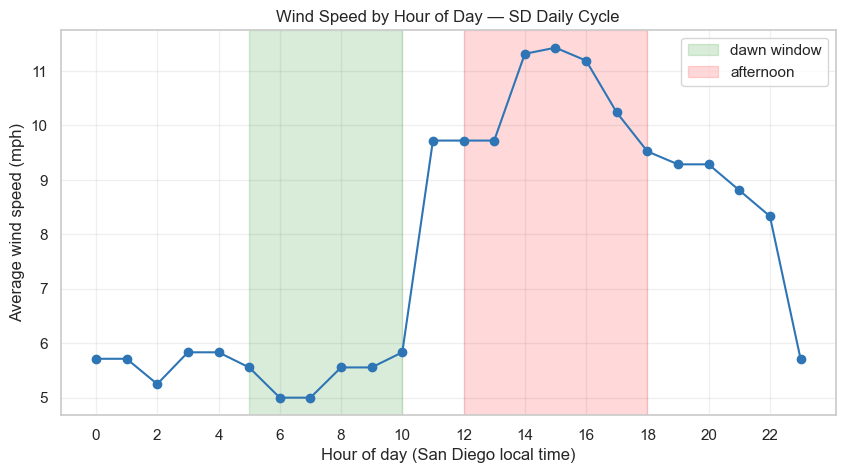

In [23]:
# Average wind speed by hour of day across all breaks
hourly_wind = wind.groupby('hour_local')['wind_speed_mph'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_wind.index, hourly_wind.values, marker='o', color='#2E75B6')
plt.axvspan(5, 10, alpha=0.15, color='green', label='dawn window')
plt.axvspan(12, 18, alpha=0.15, color='red', label='afternoon')
plt.xlabel('Hour of day (San Diego local time)')
plt.ylabel('Average wind speed (mph)')
plt.title('Wind Speed by Hour of Day — SD Daily Cycle')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Wind is lightest at dawn (5–7am, ~5 mph) and climbs steadily through the morning, with the sharpest single-hour jump at 10–11am when the sea breeze switches on. It peaks around 3pm at ~11.5 mph then tapers into the evening. The pattern is clean and repeatable — hour of day alone captures most of the wind variance in this dataset.

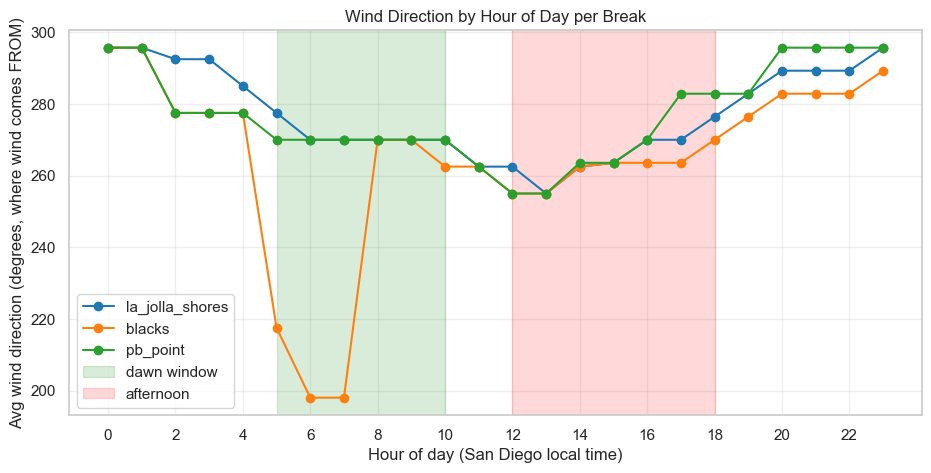

In [24]:
# Average wind direction by hour of day, per break
plt.figure(figsize=(11, 5))

for break_id in wind['break_id'].unique():
    subset = wind[wind['break_id'] == break_id]
    hourly_dir = subset.groupby('hour_local')['wind_direction_degrees'].mean()
    plt.plot(hourly_dir.index, hourly_dir.values, marker='o', label=break_id)

plt.axvspan(5, 10, alpha=0.15, color='green', label='dawn window')
plt.axvspan(12, 18, alpha=0.15, color='red', label='afternoon')
plt.xlabel('Hour of day (San Diego local time)')
plt.ylabel('Avg wind direction (degrees, where wind comes FROM)')
plt.title('Wind Direction by Hour of Day per Break')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

All three breaks sit in the 260–300° range (westerly, onshore) through most of the day. Blacks is the outlier at dawn — direction dips toward ~198° (SSW) around 6–7am before rejoining the others. This brief offshore-adjacent shift may contribute to slightly better early-morning conditions at Blacks. Overall, the direction range is narrow and consistently onshore, so wind speed is the stronger quality signal for the model.

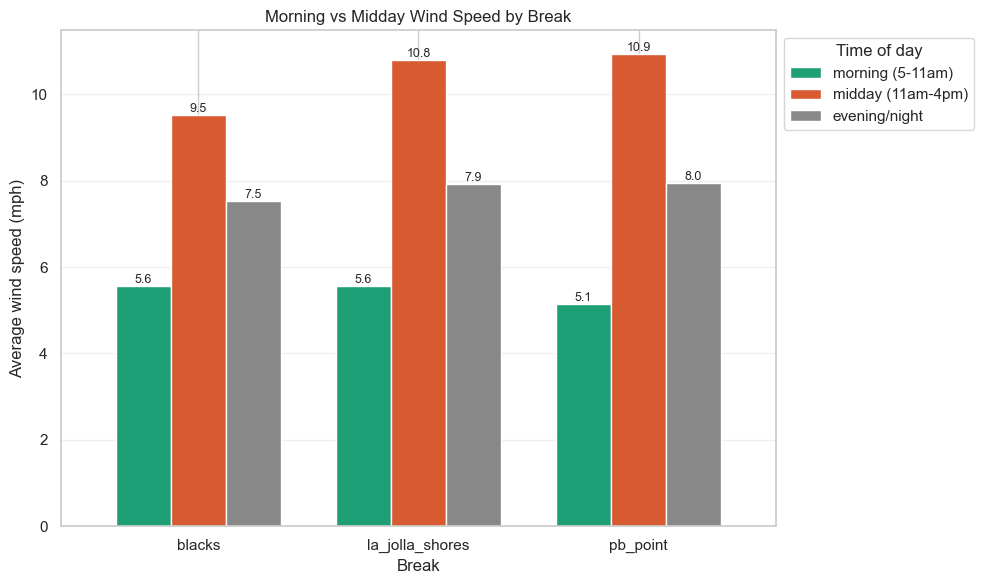

In [25]:
def classify_time(h):
    if 5 <= h < 11:    return 'morning (5-11am)'
    elif 11 <= h < 16: return 'midday (11am-4pm)'
    else:              return 'evening/night'

wind['time_block'] = wind['hour_local'].map(classify_time)

pivot = wind.groupby(['break_id', 'time_block'])['wind_speed_mph'].mean().unstack()
pivot = pivot[['morning (5-11am)', 'midday (11am-4pm)', 'evening/night']]

ax = pivot.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#1D9E75', '#D85A30', '#888888'],
    width=0.75,
)
plt.xlabel('Break')
plt.ylabel('Average wind speed (mph)')
plt.title('Morning vs Midday Wind Speed by Break')
plt.xticks(rotation=0)
plt.legend(title='Time of day', loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)
plt.tight_layout()
plt.show()

Wind roughly doubles from morning to midday at every break: Blacks 5.6→9.5 mph, La Jolla 5.6→10.8 mph, PB Point 5.1→10.9 mph. Morning speeds are nearly identical across all three (~5 mph), which makes sense since the sea breeze hasn't differentiated by local geography yet. Midday spreads out more as local effects take hold. The consistency of this doubling across breaks suggests a single `time_of_day` feature will generalize well rather than needing break-specific wind terms.